# Neural Network Regression with Tensorflow

In [1]:
# import Tensorflow
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
tf.__version__

'2.21.0'

In [3]:
# Create features
X = tf.constant([-7.0, -4.0, -1.0, 2.0, 5.0, 8.0, 11.0, 14.0],dtype='float32')

# Create labels
y = tf.constant([3.0, 6.0, 9.0, 12.0, 15.0, 18.0, 21.0, 24.0],dtype='float32')

X,y

(<tf.Tensor: shape=(8,), dtype=float32, numpy=array([-7., -4., -1.,  2.,  5.,  8., 11., 14.], dtype=float32)>,
 <tf.Tensor: shape=(8,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18., 21., 24.], dtype=float32)>)

In [4]:
print(X)
print(tf.expand_dims(X, axis = 1))

tf.Tensor([-7. -4. -1.  2.  5.  8. 11. 14.], shape=(8,), dtype=float32)
tf.Tensor(
[[-7.]
 [-4.]
 [-1.]
 [ 2.]
 [ 5.]
 [ 8.]
 [11.]
 [14.]], shape=(8, 1), dtype=float32)


## Helper functions

In [5]:
def make_prediction(model, value):
    value = tf.expand_dims(tf.constant(value), 1)
    y_pred = model.predict(value)
    return y_pred.flatten()[0]

In [6]:
tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

model.compile(
    loss = tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.SGD(),
    metrics = ['mae']
)

history = model.fit(tf.expand_dims(X, axis=1), y, epochs=10)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 697ms/step - loss: 21.7647 - mae: 21.7647
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 21.3716 - mae: 21.3716
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 20.9785 - mae: 20.9785
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 20.5867 - mae: 20.5867
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 20.3055 - mae: 20.3055
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 20.0242 - mae: 20.0242
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 19.7430 - mae: 19.7430
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 19.4617 - mae: 19.4617
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 19.1805 - mae: 19.1805
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 18.8992 - mae: 18.8992


In [7]:
df = pd.DataFrame(history.history)
df

,loss,mae
0,21.764717,21.764717
1,21.371593,21.371593
2,20.978468,20.978468
3,20.586739,20.586739
4,20.305489,20.305489
5,20.024239,20.024239
6,19.742989,19.742989
7,19.461739,19.461739
8,19.180489,19.180489
9,18.899239,18.899239


In [8]:
output = make_prediction(model=model, value=[17.0])
print(output)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
-19.097532


## Imporving the model

In [9]:
tf.random.set_seed(42)

model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

model_2.compile(
    loss = tf.keras.losses.mae,
    optimizer = tf.keras.optimizers.SGD(),
    metrics=['mae']
)

history_2 = model_2.fit(tf.expand_dims(X, axis=1), y, epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 643ms/step - loss: 7.8636 - mae: 7.8636
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - loss: 7.7311 - mae: 7.7311
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 7.5986 - mae: 7.5986
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 7.4775 - mae: 7.4775
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 7.4719 - mae: 7.4719
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 7.4663 - mae: 7.4663
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 7.4606 - mae: 7.4606
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 7.4550 - mae: 7.4550
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 7.4494 - mae: 7.4494
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 7.4437 - mae: 7.4437
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 7.4381 - mae: 7.4381
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 7.4325 - mae: 7.4325
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/s

In [10]:
output_2 = make_prediction(model=model_2, value=[17.0])
print(output_2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
29.919344


### Model 3

In [11]:
model_3 = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(1)
])

model_3.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.SGD(),
    metrics=['mae']
)

history_3 = model_3.fit(tf.expand_dims(X, axis=1), y, epochs=100, verbose=False)

In [12]:
output_3 = make_prediction(model_3, value = [17.0])
output_3

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


np.float32(32.097286)

### Model 4

In [13]:
model_4 = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(1)
])

model_4.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    metrics=['mae']
)

history_4 = model_4.fit(
    tf.expand_dims(X, axis=1), 
    y, 
    epochs=100, 
    verbose=True
)

output_4 = make_prediction(model_4, value = [17.0])
output_4

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 565ms/step - loss: 13.7289 - mae: 13.7289
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 13.1935 - mae: 13.1935
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 12.6634 - mae: 12.6634
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 12.1278 - mae: 12.1278
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 11.5920 - mae: 11.5920
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 11.0525 - mae: 11.0525
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - loss: 10.4948 - mae: 10.4948
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 9.9095 - mae: 9.9095
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 9.3008 - mae: 9.3008
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 8.6544 - mae: 8.6544
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 7.9748 - mae: 7.9748
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 7.2562 - mae: 7.2562
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━

np.float32(31.373993)

In [14]:
output, output_2, output_3, output_4

(np.float32(-19.097532),
 np.float32(29.919344),
 np.float32(32.097286),
 np.float32(31.373993))

## Simple Example

In [15]:
X = np.arange(-100, 100, 4)
y = X + 4

df = pd.DataFrame({
    "X": X,
    "y": y
})
print(df.X.shape, df.y.shape)

(50,) (50,)


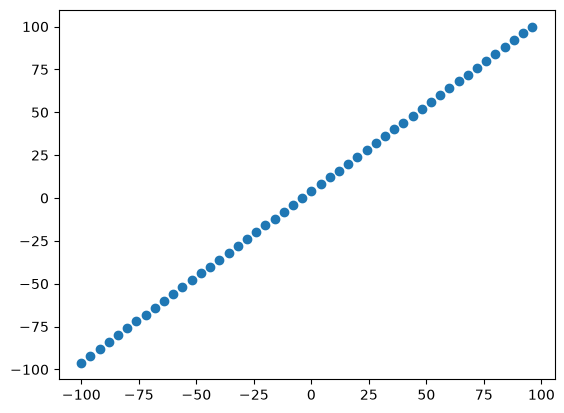

In [16]:
plt.scatter(X,y)
plt.show()

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (40,)
Shape of X_test: (10,)
Shape of y_train: (40,)
Shape of y_test: (10,)


In [ ]:
# Let's have a look at how to build a neural network

# 1. Create a model
model_5 = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,), name="input_layer"),
    tf.keras.layers.Dense(10, activation="relu", name="hidden_layer_1"),
    tf.keras.layers.Dense(10, activation="relu", name="hidden_layer_2"),
    tf.keras.layers.Dense(5, activation="relu", name="hidden_layer_3"),
    tf.keras.layers.Dense(1, name="output_layer")
], name="Model_5")

# 2. Compile the model
model_5.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics=['mae']
)

In [46]:
model_5.summary()

Model: "Model_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_3 (Dense)          │ (None, 5)              │            55 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 191 (764.00 B)

 Trainable params: 191 (764.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Fitting the model

X_train = tf.reshape(X_train, (-1, 1))
X_test = tf.reshape(X_test, (-1, 1))

history_5 = model_5.fit(X_train, y_train, epochs=100, verbose=0)

output_5 = model_5.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step


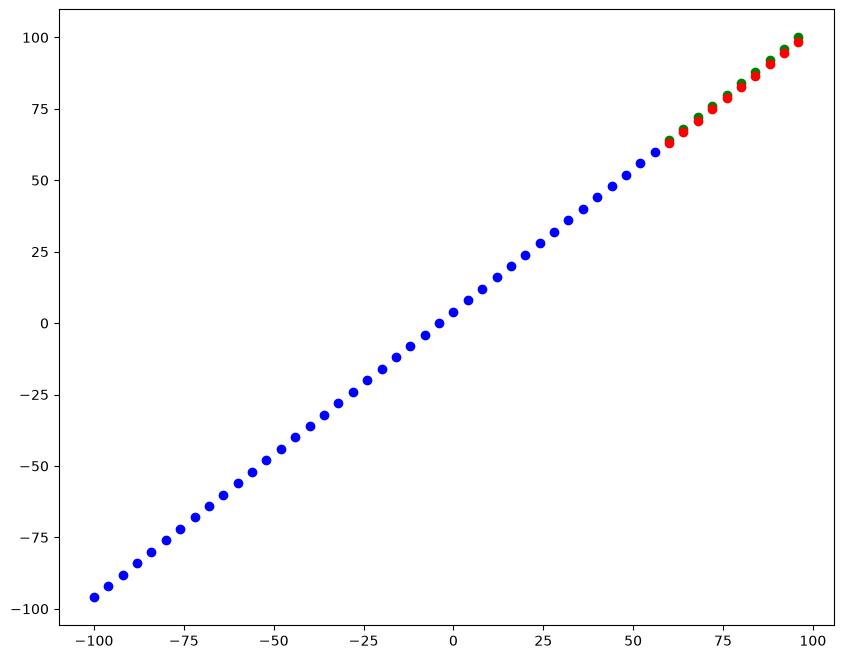

In [48]:
plt.figure(figsize=(10,8))
plt.scatter(X_train, y_train, label="Training Data", color="blue")
plt.scatter(X_test, y_test, label="Test Data", color="green")
plt.scatter(X_test, output_5, label="Predictions", color="red")
plt.show()

In [ ]:
model_5.evaluate(X_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - loss: 1.3080 - mae: 1.3080


[1.3080284595489502, 1.3080284595489502]

# Large Example

In [72]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [73]:
df = pd.read_csv("https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/refs/heads/master/insurance.csv")
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [75]:
# Information of dataset
print(df.head())
print("-"*100)
print(df.tail())
print("-"*100)
print(df.info())
print("-"*100)

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
----------------------------------------------------------------------------------------------------
      age     sex    bmi  children smoker     region     charges
1333   50    male  30.97         3     no  northwest  10600.5483
1334   18  female  31.92         0     no  northeast   2205.9808
1335   18  female  36.85         0     no  southeast   1629.8335
1336   21  female  25.80         0     no  southwest   2007.9450
1337   61  female  29.07         0    yes  northwest  29141.3603
----------------------------------------------------------------------------------------------------
<class 'pandas.DataFrame

In [77]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [78]:
# data type checking
df.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [88]:
# encoding
for feature in list(df.select_dtypes(include='str').columns):
    encoder = LabelEncoder()
    df[feature] = encoder.fit_transform(df[feature])

In [89]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [90]:
# Splitting data in X & y
X = df.drop(columns=["charges"])
y = df[["charges"]]

# creating training and test data
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

In [91]:
X.shape, y.shape

((1338, 6), (1338, 1))

In [ ]:
# Building the Neural Network Regression Model

# random seed
tf.random.set_seed(42)

# 1. Creating the model
insurance_model_1 = tf.keras.Sequential([
    tf.keras.layers.Dense(10, activation="relu"),
    tf.keras.layers.Dense(1)
])

# 2. Compiling the model
insurance_model_1.compile(loss=tf.keras.losses.mae,
              optimizer = tf.keras.optimizers.Adam(learning_rate=0.01),
              metrics=['mae'])

# 3. fitting the model
history_insurance_1 = insurance_model_1.fit(X_train,y_train,epochs=100)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 13289.4102 - mae: 13289.4102
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 13096.7988 - mae: 13096.7988
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 12728.9453 - mae: 12728.9453
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 12146.4678 - mae: 12146.4678 
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 11347.9238 - mae: 11347.9238
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 10409.2344 - mae: 10409.2344
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9468.4336 - mae: 9468.4336
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 8622.0996 - mae: 8622.0996
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7984.7241 - mae: 7984.7241
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7613.4292 - mae: 7613.4292
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7472.5273 - mae: 7472.5273
Epoch 12/100
34/34 ━━━━━━━━━━━━━━━━━━━

In [100]:
# Building the Neural Network Regression Model

# random seed
tf.random.set_seed(42)

# 1. Creating the model
insurance_model_2 = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(50, activation="relu"),
    tf.keras.layers.Dense(1)
])

# 2. Compiling the model
insurance_model_2.compile(
    loss=tf.keras.losses.mae,
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics=['mae']
)

# 3. fitting the model
history_insurance_2 = insurance_model_2.fit(X_train,y_train,epochs=100)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 11999.1865 - mae: 11999.1865
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7547.9395 - mae: 7547.9395
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7288.2046 - mae: 7288.2046
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7112.5923 - mae: 7112.5923
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6910.8696 - mae: 6910.8696
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6700.6211 - mae: 6700.6211
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6561.0527 - mae: 6561.0527
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6487.4468 - mae: 6487.4468
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6421.6064 - mae: 6421.6064
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6359.2847 - mae: 6359.2847
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6266.5688 - mae: 6266.5688
Epoch 12/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/ste

In [101]:
# Comparing with previous models..
insurance_model_1.evaluate(X_test,y_test)
insurance_model_2.evaluate(X_test,y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 6144.4204 - mae: 6144.4204
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2096.9194 - mae: 2096.9194  


[2096.91943359375, 2096.91943359375]

In [102]:
# plot the learning_curve
h = history_insurance_2.history
insurance_model_2_learning_curve = pd.DataFrame(h['mae'], columns=['mae'])
insurance_model_2_learning_curve

,mae
0,11999.186523
1,7547.939453
2,7288.204590
3,7112.592285
4,6910.869629
...,...
95,2493.872314
96,2508.155762
97,2500.540771
98,2460.573242


Text(0, 0.5, 'Loss')

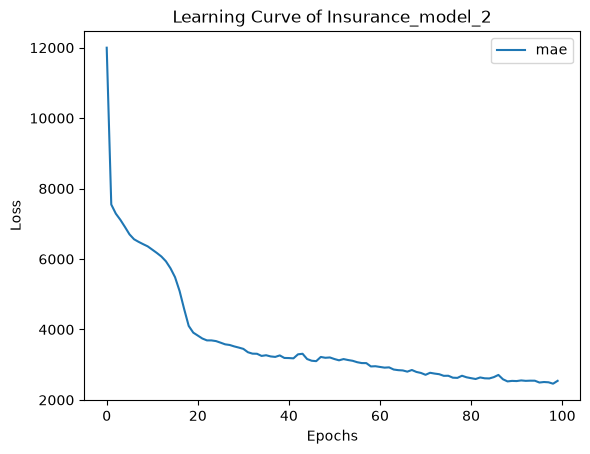

In [103]:
insurance_model_2_learning_curve.plot()
plt.title("Learning Curve of Insurance_model_2")
plt.xlabel("Epochs")
plt.ylabel("Loss")

## Early Stopping Callback

In [104]:
# Building the Neural Network Regression Model

# random seed
tf.random.set_seed(42)

callback = tf.keras.callbacks.EarlyStopping(
    monitor='loss',
    patience=3
)

# 1. Creating the model
insurance_model_3_earlystop = tf.keras.Sequential([
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(50, activation="relu"),
    tf.keras.layers.Dense(1)
])

# 2. Compiling the model
insurance_model_3_earlystop.compile(
    loss=tf.keras.losses.mae,
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics=['mae']
)

# 3. fitting the model
history_insurance_3_earlystop = insurance_model_3_earlystop.fit(
    X_train,
    y_train,
    epochs=500
)

Epoch 1/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 11829.4688 - mae: 11829.4688
Epoch 2/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7581.5303 - mae: 7581.5303
Epoch 3/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 7291.4814 - mae: 7291.4814
Epoch 4/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7106.7949 - mae: 7106.7949
Epoch 5/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6898.4473 - mae: 6898.4473
Epoch 6/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6680.1396 - mae: 6680.1396
Epoch 7/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6535.6519 - mae: 6535.6519
Epoch 8/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6456.4761 - mae: 6456.4761
Epoch 9/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 6366.2290 - mae: 6366.2290
Epoch 10/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6274.9077 - mae: 6274.9077
Epoch 11/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6167.4131 - mae: 6167.4131
Epoch 12/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/ste

In [105]:
insurance_model_3_earlystop.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 100)            │           700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,405 (67.99 KB)

 Trainable params: 5,801 (22.66 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 11,604 (45.33 KB)

Text(0, 0.5, 'Loss')

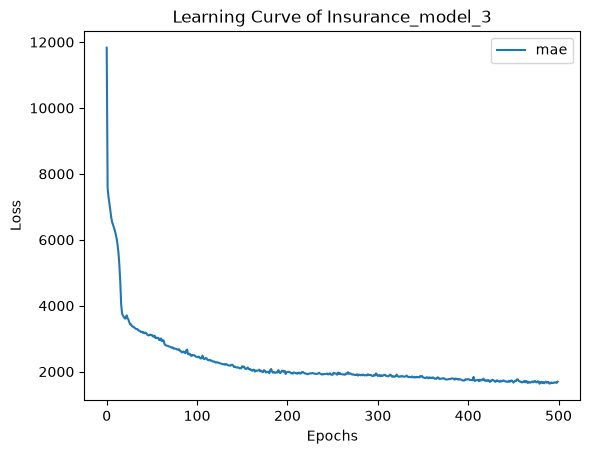

In [108]:
h = history_insurance_3_earlystop.history
insurance_model_3_earlystop_learningCurve = pd.DataFrame(h['mae'], columns=['mae'])

insurance_model_3_earlystop_learningCurve.plot()
plt.title("Learning Curve of Insurance_model_3")
plt.xlabel("Epochs")
plt.ylabel("Loss")

In [109]:
insurance_model_1.evaluate(X_test,y_test)
insurance_model_2.evaluate(X_test,y_test)
insurance_model_3_earlystop.evaluate(X_test,y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 6144.4204 - mae: 6144.4204 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 2096.9194 - mae: 2096.9194 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1416.5638 - mae: 1416.5638


[1416.5638427734375, 1416.5638427734375]